# Clasificador de Dirección de la Volatilidad — Barras de AAPL de 1 minuto

**Objetivo:** Predecir si la volatilidad observada in la *hora siguiente* será **mayor o menor** que en la *hora actual*, usando las últimas 60 barras de 1 minuto como ventana de contexto.

**Modelo:** Random Forest Classifier (scikit-learn). También se hace una experimentación con Catboost.

**Contexto de la pipeline:** En producción (Apache Beam / GCP Dataflow), el modelo recibe una venta de 60 barras de 1 minuto y retorna una predicción usando clasificación binaria: `1` = aumenta la volatilidad, `0` = disminuye la volatilidad.

---
### Secciones
1. Instalación de dependencias e importación
2. Carga de datos
3. Ingeniería de features
4. Construcción de la label
5. División entrenamiento / evaluación
6. Entrenamiento del Random Forest
7. Evaluación
8. Función de inferencia en producción (compatible con Beam)
9. Guardado de los modelos

## 1. Instalación de dependencias e importación

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

## 2. Carga de los datos

Hemos cargado los datos directamente al a sesión de Colab para este experimiento. El archivo es el que se produjo como resultado del scraper de datos de las acciones. Cargamos los datos y analizamos las columnas del dataset.

In [ ]:
# ── CONFIG ──────────────────────────────────────────────────────────────────
DATA_PATH = 'AAPL_bars.parquet'
WINDOW     = 60                    # context window: 60 one-minute bars = 1 hour
# ────────────────────────────────────────────────────────────────────────────

df = pd.read_parquet(DATA_PATH)
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values('timestamp').reset_index(drop=True)

print(f'Shape: {df.shape}')
print(f'Date range: {df.timestamp.min()} → {df.timestamp.max()}')
df.head()

Shape: (376212, 9)
Date range: 2024-01-02 09:00:00+00:00 → 2026-01-01 00:58:00+00:00


,close,high,low,n,open,timestamp,volume,vw,symbol
0,190.20,191.52,190.00,612,191.52,2024-01-02 09:00:00+00:00,18933,190.241493,AAPL
1,190.00,190.13,190.00,425,190.11,2024-01-02 09:01:00+00:00,8562,190.088775,AAPL
2,189.82,189.90,189.82,129,189.90,2024-01-02 09:02:00+00:00,5355,189.823988,AAPL
3,189.87,189.87,189.80,83,189.87,2024-01-02 09:03:00+00:00,4405,189.859107,AAPL
4,189.90,189.95,189.90,87,189.90,2024-01-02 09:04:00+00:00,2225,189.916633,AAPL


## 3. Ingeniería de características

### Elemento clave: la ventana de contexto

En producción (Beam), cada predicción se activa a partir de una **ventana deslizante de 60 barras de un minuto**.
Las features que se muestran a continuación resumen esa ventana en un vector de features de longitud fija.

Todas las features se calculan primero por barra individual y, después, el resumen de la ventana se calcula por fila.

### Features utilizadas
| Feature | Descripción |
|---|---|
| `realized_vol` | Desviación típica de los log-retornos sobre las últimas 60 barras — la señal principal |
| `vol_lag_1..3` | Volatilidad realizada retardada — captura la agrupación (clustering) de volatilidad |
| `mean_return` | Log-retorno medio sobre la ventana — señal de dirección |
| `abs_return` | Retorno absoluto medio — intensidad del movimiento de precios |
| `price_range` | Media de (high - low) / close — rango intrabarra |
| `volume_mean` | Volumen medio sobre la ventana — proxy de liquidez |
| `volume_std` | Desviación típica del volumen — señal de actividad inusual |
| `n_mean` | Número medio de operaciones — intensidad de negociación |
| `vwap_spread` | Media de abs(close - vw) / vw — desviación del precio respecto al VWAP |

In [ ]:
# ── Per-bar base features ────────────────────────────────────────────────────

df['log_return']  = np.log(df['close'] / df['close'].shift(1))
df['price_range'] = (df['high'] - df['low']) / df['close']
df['vwap_spread'] = np.abs(df['close'] - df['vw']) / df['vw']

# ── Rolling window features (60-bar = 1 hour) ────────────────────────────────

df['realized_vol'] = df['log_return'].rolling(WINDOW).std()
df['vol_lag_1']    = df['realized_vol'].shift(WINDOW)
df['vol_lag_2']    = df['realized_vol'].shift(WINDOW * 2)
df['vol_lag_3']    = df['realized_vol'].shift(WINDOW * 3)

df['mean_return']  = df['log_return'].rolling(WINDOW).mean()
df['abs_return']   = df['log_return'].abs().rolling(WINDOW).mean()
df['volume_mean']  = df['volume'].rolling(WINDOW).mean()
df['volume_std']   = df['volume'].rolling(WINDOW).std()
df['n_mean']       = df['n'].rolling(WINDOW).mean()
df['range_mean']   = df['price_range'].rolling(WINDOW).mean()
df['vwap_mean']    = df['vwap_spread'].rolling(WINDOW).mean()

print('Features computed.')
df[['timestamp','realized_vol','vol_lag_1','mean_return','volume_mean']].dropna().head()

Features computed.


,timestamp,realized_vol,vol_lag_1,mean_return,volume_mean
120,2024-01-02 12:18:00+00:00,0.000576,0.000293,-0.000068,3108.483333
121,2024-01-02 12:19:00+00:00,0.000552,0.000314,-0.000040,2976.216667
122,2024-01-02 12:20:00+00:00,0.000528,0.000332,-0.000020,2948.683333
123,2024-01-02 12:21:00+00:00,0.000528,0.000330,-0.000017,2950.050000
124,2024-01-02 12:22:00+00:00,0.000522,0.000338,-0.000009,2941.583333


## 4. Construcción de las etiquetas

**Etiqueta = 1** si la volatilidad realizada en la *siguiente* ventana de 60 barras es **mayor** que la actual.  
**Etiqueta = 0** si es **menor o igual**.

Esta es exactamente la predicción que hará nuestra pipeline de Beam: dadas las últimas 60 barras, ¿será la próxima hora más o menos volátil?

In [ ]:
# Next-period vol = realized_vol shifted back by WINDOW bars
df['next_vol'] = df['realized_vol'].shift(-WINDOW)

# Binary label: 1 = vol going up, 0 = vol going down
df['label'] = (df['next_vol'] > df['realized_vol']).astype(int)

# Drop rows with NaN (edges of the dataset)
FEATURE_COLS = [
    'realized_vol', 'vol_lag_1', 'vol_lag_2', 'vol_lag_3',
    'mean_return', 'abs_return',
    'volume_mean', 'volume_std',
    'n_mean', 'range_mean', 'vwap_mean'
]

df_model = df[FEATURE_COLS + ['label', 'timestamp']].dropna().reset_index(drop=True)

print(f'Rows available for modelling: {len(df_model):,}')
print(f'Label distribution:\n{df_model.label.value_counts(normalize=True).rename({1:"vol up", 0:"vol down"}).round(3)}')

Rows available for modelling: 375,972
Label distribution:
label
vol down    0.56
vol up      0.44
Name: proportion, dtype: float64


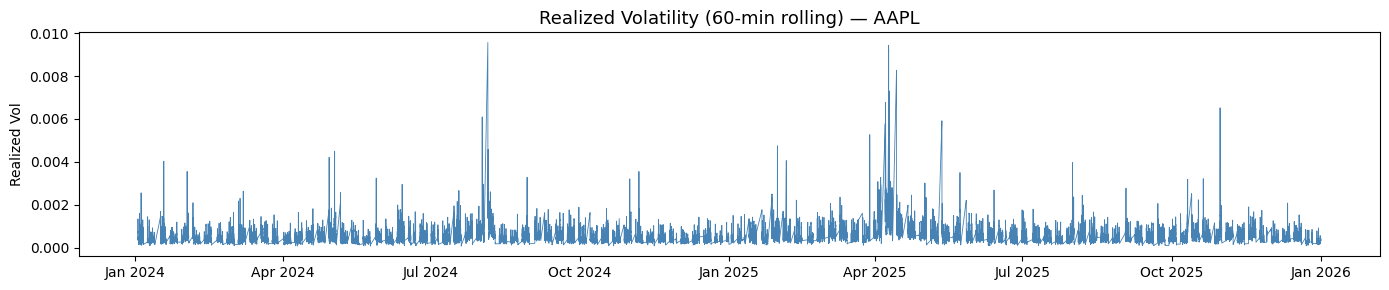

In [ ]:
# ── Quick sanity plot: realized vol over time ────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(df_model['timestamp'], df_model['realized_vol'], lw=0.6, color='steelblue')
ax.set_title('Realized Volatility (60-min rolling) — AAPL', fontsize=13)
ax.set_ylabel('Realized Vol')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.show()

## 5. Train / Test Split

**Importante:** utilizamos una **división basada en tiempo**, NO una mezcla aleatoria.  
La mezcla aleatoria provocaría fuga de datos (*data leakage*); datos futuros que se filtran en el entrenamiento.  
Entrenamos con el primer 80% del tiempo y evaluamos con el último 20%.

In [ ]:
SPLIT = 0.80
split_idx = int(len(df_model) * SPLIT)

train = df_model.iloc[:split_idx]
test  = df_model.iloc[split_idx:]

X_train = train[FEATURE_COLS]
y_train = train['label']
X_test  = test[FEATURE_COLS]
y_test  = test['label']

print(f'Train: {len(train):,} rows  |  {train.timestamp.min().date()} → {train.timestamp.max().date()}')
print(f'Test:  {len(test):,} rows   |  {test.timestamp.min().date()} → {test.timestamp.max().date()}')

Train: 300,777 rows  |  2024-01-02 → 2025-08-01
Test:  75,195 rows   |  2025-08-01 → 2026-01-01


## 6. Ajuste del Random Forest

Cada árbol se construye con dos fuentes de aleatoriedad, que son las que hacen que el bosque sea diverso:

**1. Bootstrap de muestras.**  
Cada árbol recibe una muestra aleatoria *con reemplazamiento* del conjunto de entrenamiento (aproximadamente el 63% de las filas únicas). Las filas no seleccionadas se denominan *out-of-bag* y sirven como validación interna gratuita.

**2. Selección aleatoria de features en cada nodo.**  
En cada nodo del árbol, el algoritmo no evalúa las 11 features disponibles, sino solo un subconjunto aleatorio de ellas (por defecto, √11 ≈ 3). Elige la mejor entre ese subconjunto para hacer el split.

Cada nodo divide los datos buscando el umbral que maximiza la **reducción de impureza de Gini**. Por ejemplo, un nodo podría aprender:

> *"Si `realized_vol > 0.0043` y `vol_lag_1 > 0.0038` → predice `label = 1`"*

La definición de aumento de volatilidad es:

```python
(df['next_vol'] > df['realized_vol']).astype(int)
```

Esta definición convierte el problema en **clasificación binaria de cambio de régimen de volatilidad**: el modelo no predice el nivel absoluto de volatilidad, sino si la próxima hora será *más* volátil que la actual. Esto es más robusto que una regresión, ya que solo necesita capturar la *dirección* del cambio, no su magnitud exacta.


In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,       # enough trees for stable estimates
    max_depth=8,            # shallow trees — reduces overfitting on financial data
    min_samples_leaf=50,    # avoid fitting noise; each leaf needs meaningful sample
    max_features='sqrt',    # standard RF setting
    class_weight='balanced',# handles mild class imbalance automatically
    random_state=42,
    n_jobs=-1               # use all CPU cores
)

rf.fit(X_train, y_train)
print('Model trained.')

Model trained.


## 7. Evaluación

In [ ]:
y_pred      = rf.predict(X_test)
y_pred_prob = rf.predict_proba(X_test)[:, 1]

print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['vol down', 'vol up']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_pred_prob):.4f}')

=== Classification Report ===
              precision    recall  f1-score   support

    vol down       0.79      0.72      0.75     42629
      vol up       0.67      0.75      0.71     32566

    accuracy                           0.73     75195
   macro avg       0.73      0.74      0.73     75195
weighted avg       0.74      0.73      0.74     75195

ROC-AUC: 0.8041


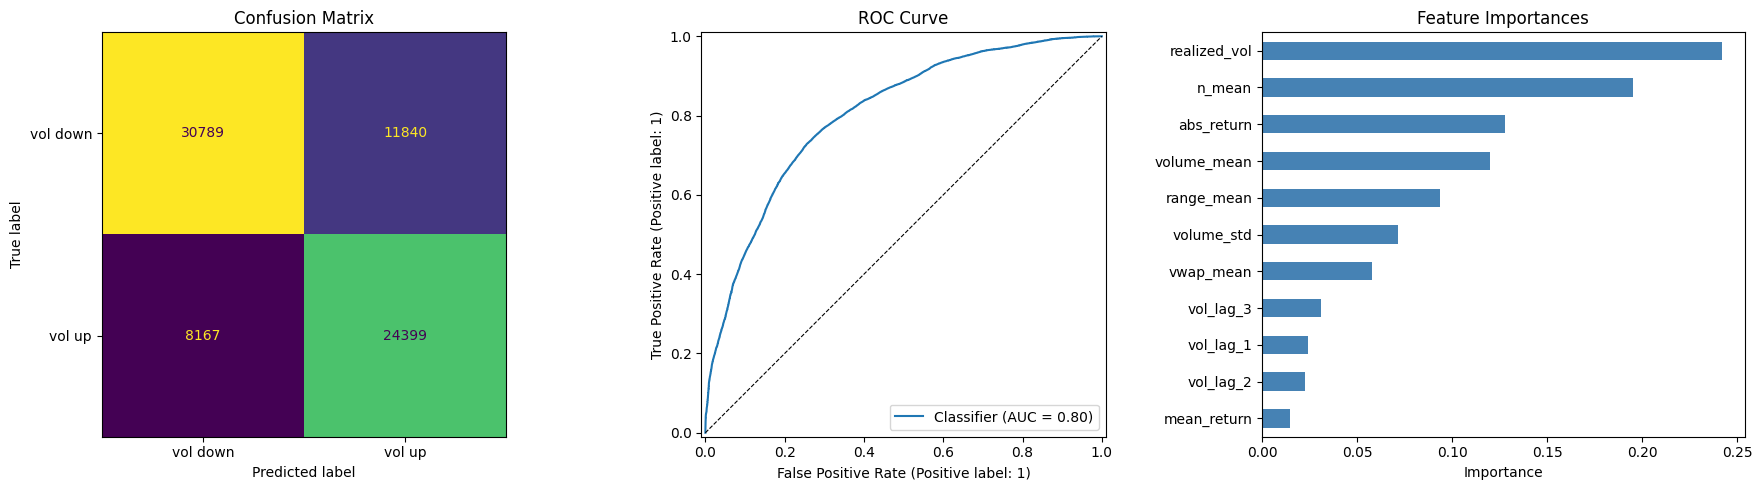

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── 1. Confusion matrix ──────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['vol down', 'vol up']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix')

# ── 2. ROC curve ─────────────────────────────────────────────────────────────
RocCurveDisplay.from_predictions(y_test, y_pred_prob, ax=axes[1])
axes[1].set_title('ROC Curve')
axes[1].plot([0,1],[0,1],'k--', lw=0.8)

# ── 3. Feature importances ───────────────────────────────────────────────────
importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values()
importances.plot(kind='barh', ax=axes[2], color='steelblue')
axes[2].set_title('Feature Importances')
axes[2].set_xlabel('Importance')

plt.tight_layout()
plt.show()

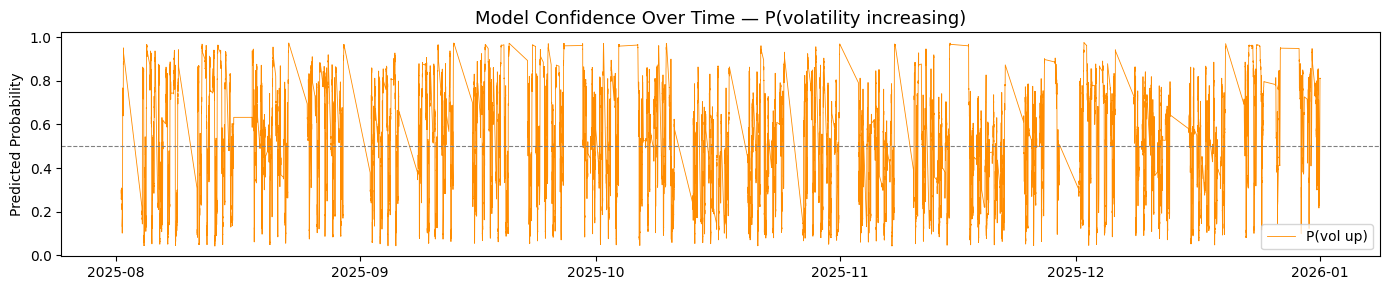

In [ ]:
# ── Predicted probability over time (test set) ───────────────────────────────
# Useful for observability: you can log this value per prediction in your pipeline

fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(test['timestamp'].values, y_pred_prob, lw=0.6, color='darkorange', label='P(vol up)')
ax.axhline(0.5, color='gray', lw=0.8, linestyle='--')
ax.set_title('Model Confidence Over Time — P(volatility increasing)', fontsize=13)
ax.set_ylabel('Predicted Probability')
ax.legend()
plt.tight_layout()
plt.show()

## 7B. Comparison with Catboost

Random Forest entrena *N* árboles **en paralelo e independientes** y promedia sus votos (*bagging*).  
CatBoost, en cambio, entrena árboles **en secuencia**, donde cada árbol nuevo corrige los errores del anterior (*boosting*).

El proceso es iterativo:

1. Se entrena un árbol simple sobre los datos.
2. Se calculan los **residuos** — la diferencia entre la predicción actual y la realidad.
3. El siguiente árbol aprende a predecir esos residuos, no la label directamente.
4. Se repite el proceso durante *N* iteraciones, acumulando árboles que se suman con un **learning rate** que controla cuánto corrige cada uno.

La predicción final es la **suma ponderada** de todos los árboles, no una votación.

A diferencia de otros algoritmos de boosting (XGBoost, LightGBM), CatBoost implementa **Ordered Boosting**: calcula los residuos usando solo datos anteriores en el tiempo para evitar *target leakage* durante el entrenamiento. Esto lo hace especialmente adecuado para datos con estructura temporal, como es el caso de este dataset de volatilidad.

Además, CatBoost construye árboles **simétricos** (cada nivel aplica el mismo split en todas las ramas), lo que lo hace más rápido en inferencia y más estable frente al sobreajuste.

En esta sección crearemos un modelo con CatBoost para comparar los resultados con los de Random Forest Classifier.

In [ ]:
!pip install catboost -q
from catboost import CatBoostClassifier

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 23.6 MB/s eta 0:00:00


## 7C. Model Training

In [ ]:
catboost = CatBoostClassifier(
    iterations=1000,          # number of trees — equivalent to n_estimators
    depth=6,                 # shallow trees work well for financial data
    learning_rate=0.05,      # lower = more robust, slower
    loss_function='Logloss', # binary classification
    eval_metric='AUC',
    class_weights=[1, 1.3],  # slight upweight on vol_up (minority class)
    early_stopping_rounds=50,# stops if AUC doesn't improve — prevents overfitting
    random_seed=42,
    verbose=100              # prints progress every 100 iterations
)

catboost.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),  # monitors AUC on test set during training
    plot=True                    # shows training curve in Colab
)

print('Model trained.')

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	test: 0.7733475	best: 0.7733475 (0)	total: 20.5ms	remaining: 20.5s
100:	test: 0.8060328	best: 0.8060328 (100)	total: 1.85s	remaining: 16.4s
200:	test: 0.8107737	best: 0.8107737 (200)	total: 3.67s	remaining: 14.6s
300:	test: 0.8136732	best: 0.8136732 (300)	total: 5.69s	remaining: 13.2s
400:	test: 0.8149566	best: 0.8149566 (400)	total: 7.83s	remaining: 11.7s
500:	test: 0.8155425	best: 0.8155425 (500)	total: 9.68s	remaining: 9.64s
600:	test: 0.8158299	best: 0.8160797 (570)	total: 11.5s	remaining: 7.65s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8160797055
bestIteration = 570

Shrink model to first 571 iterations.
Model trained.


## 7D Evaluation

In [ ]:
y_pred_catboost      = catboost.predict(X_test)
y_pred_prob_catboost = catboost.predict_proba(X_test)[:, 1]

print('=== Classification Report ===')
print(classification_report(y_test, y_pred_catboost, target_names=['vol down', 'vol up']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_pred_prob_catboost):.4f}')

=== Classification Report ===
              precision    recall  f1-score   support

    vol down       0.78      0.75      0.77     42629
      vol up       0.69      0.72      0.71     32566

    accuracy                           0.74     75195
   macro avg       0.74      0.74      0.74     75195
weighted avg       0.74      0.74      0.74     75195

ROC-AUC: 0.8161


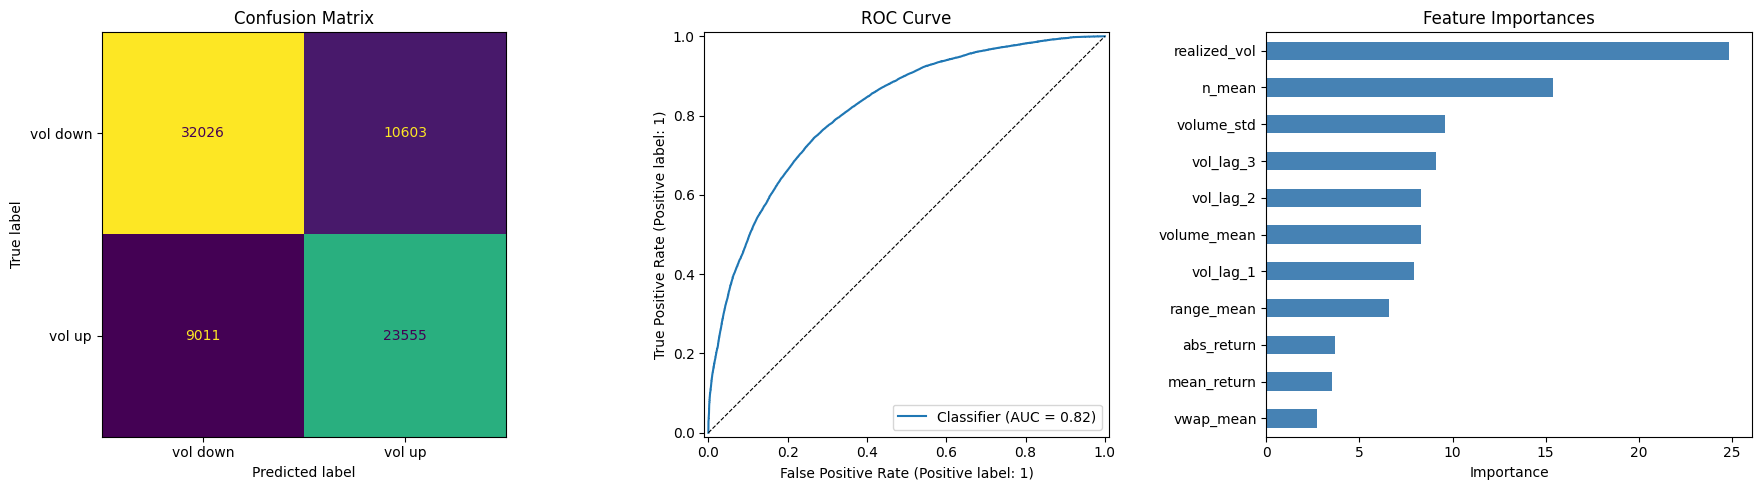

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── 1. Confusion matrix ──────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_catboost)
ConfusionMatrixDisplay(cm, display_labels=['vol down', 'vol up']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix')

# ── 2. ROC curve ─────────────────────────────────────────────────────────────
RocCurveDisplay.from_predictions(y_test, y_pred_prob_catboost, ax=axes[1])
axes[1].set_title('ROC Curve')
axes[1].plot([0,1],[0,1],'k--', lw=0.8)

# ── 3. Feature importances ───────────────────────────────────────────────────
importances = pd.Series(catboost.get_feature_importance(), index=FEATURE_COLS).sort_values()
importances.plot(kind='barh', ax=axes[2], color='steelblue')
axes[2].set_title('Feature Importances')
axes[2].set_xlabel('Importance')

plt.tight_layout()
plt.show()

## 8. Función de inferencia en producción (compatible con Beam)

Esta es un ejemplo de cómo la función `DoFn` de Apache Beam funcionaría en producción.

**Entrada:** un DataFrame de exactamente 60 barras de un minuto (una ventana deslizante)  
**Salida:** `{'prediction': 0 o 1, 'probability': float, 'label': 'vol_up' o 'vol_down'}`

La función calcula las features a partir de las barras en bruto y llama al modelo entrenado; no se necesita ningún estado de preprocesamiento más allá del propio archivo del modelo.

In [ ]:
def compute_features_from_window(window_df: pd.DataFrame) -> pd.Series:
    """
    Compute the feature vector from a window of 60 one-minute bars.

    Parameters
    ----------
    window_df : pd.DataFrame
        Exactly 60 rows with columns: close, high, low, open, volume, vw, n
        Sorted ascending by timestamp.

    Returns
    -------
    pd.Series with the feature vector for this window.
    """
    assert len(window_df) == 60, f'Expected 60 bars, got {len(window_df)}'

    log_ret      = np.log(window_df['close'] / window_df['close'].shift(1)).dropna()
    price_range  = (window_df['high'] - window_df['low']) / window_df['close']
    vwap_spread  = np.abs(window_df['close'] - window_df['vw']) / window_df['vw']

    realized_vol = log_ret.std()

    return pd.Series({
        'realized_vol' : realized_vol,
        'vol_lag_1'    : np.nan,   # <-- replace with state lookup in Beam
        'vol_lag_2'    : np.nan,   # <-- replace with state lookup in Beam
        'vol_lag_3'    : np.nan,   # <-- replace with state lookup in Beam
        'mean_return'  : log_ret.mean(),
        'abs_return'   : log_ret.abs().mean(),
        'volume_mean'  : window_df['volume'].mean(),
        'volume_std'   : window_df['volume'].std(),
        'n_mean'       : window_df['n'].mean(),
        'range_mean'   : price_range.mean(),
        'vwap_mean'    : vwap_spread.mean(),
    })


def predict_vol_direction(window_df: pd.DataFrame, model) -> dict:
    """
    Main inference entry point for Apache Beam DoFn.

    Parameters
    ----------
    window_df : pd.DataFrame  — 60 one-minute bars
    model     : trained RandomForestClassifier

    Returns
    -------
    dict with prediction, probability, and human-readable label
    """
    features  = compute_features_from_window(window_df)
    X         = features.values.reshape(1, -1)
    pred      = model.predict(X)[0]
    prob      = model.predict_proba(X)[0][1]   # P(vol up)

    return {
        'prediction' : int(pred),
        'probability': round(float(prob), 4),
        'label'      : 'vol_up' if pred == 1 else 'vol_down'
    }


# ── Quick smoke test on the last 60 bars of training data ────────────────────
sample_window = df.dropna(subset=['log_return']).iloc[-60:][['close','high','low','open','volume','vw','n']].copy()
result = predict_vol_direction(sample_window, rf)
print('Smoke test result:', result)

Smoke test result: {'prediction': 1, 'probability': 0.8101, 'label': 'vol_up'}


## 9. Guardado de modelos

In [ ]:
MODEL_PATH = 'vol_classifier_aapl.joblib'
joblib.dump(rf, MODEL_PATH)
print(f'Model saved to {MODEL_PATH}')

# To upload to GCS (replace with your bucket):
# !gsutil cp {MODEL_PATH} gs://your-bucket/models/{MODEL_PATH}

Model saved to vol_classifier_aapl.joblib


In [ ]:
MODEL_PATH = 'vol_classifier_aapl.joblib'
joblib.dump(rf, MODEL_PATH)
print(f'Model saved to {MODEL_PATH}')

# To upload to GCS (replace with your bucket):
# !gsutil cp {MODEL_PATH} gs://your-bucket/models/{MODEL_PATH}

In [ ]:
catboost.save_model('vol_classifier_aapl.cbm')

from google.colab import files
files.download('vol_classifier_aapl.cbm')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Load
from catboost import CatBoostClassifier

model = CatBoostClassifier()
model.load_model('vol_classifier_aapl.cbm')

CatBoostClassifier(class_weights=[1, 1.3], depth=6, eval_metric='AUC', iterations=1000, learning_rate=0.05, loss_function='Logloss', od_wait=50, random_seed=42, verbose=100)

In [ ]:
from google.colab import files

files.download('vol_classifier_aapl.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>